In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../customer_churn_data.csv')

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [4]:
df.shape

(1000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [6]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [7]:
df["InternetService"].value_counts()

InternetService
Fiber Optic    395
DSL            308
Name: count, dtype: int64

In [8]:
df["InternetService"] = df["InternetService"].fillna("Unknown")

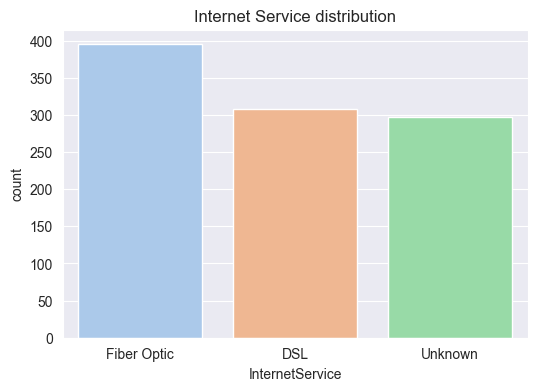

In [9]:
plt.figure(figsize = (6,4))
sns.countplot(x = 'InternetService', data= df, palette = 'pastel')
plt.title("Internet Service distribution")
plt.show()

In [10]:
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [11]:
df.shape

(1000, 10)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
def categorical_summary(df):
    cat_cols = df.select_dtypes(include = ['object', 'category']).columns
    for col in cat_cols:
        print(df[col].value_counts())
        print("_" * 30)

In [14]:
categorical_summary(df)

Gender
Female    538
Male      462
Name: count, dtype: int64
______________________________
ContractType
Month-to-Month    511
One-Year          289
Two-Year          200
Name: count, dtype: int64
______________________________
InternetService
Fiber Optic    395
DSL            308
Unknown        297
Name: count, dtype: int64
______________________________
TechSupport
Yes    506
No     494
Name: count, dtype: int64
______________________________
Churn
Yes    883
No     117
Name: count, dtype: int64
______________________________


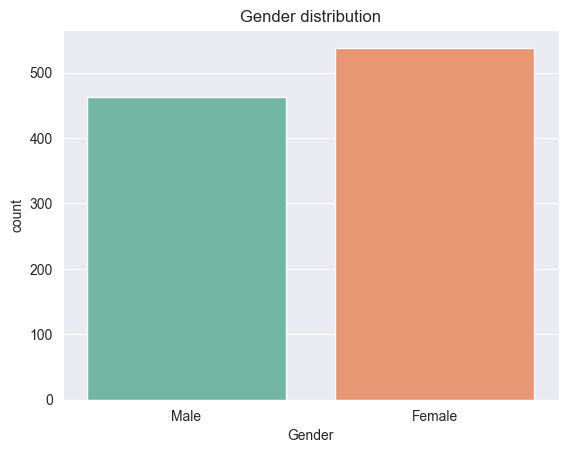

In [15]:

sns.countplot(x = 'Gender', data= df, palette= 'Set2')
plt.title("Gender distribution")
plt.show()

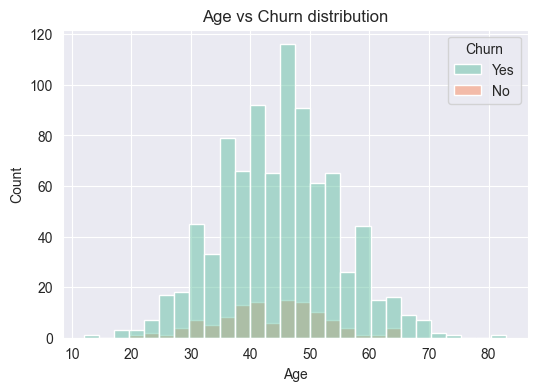

In [16]:
plt.figure(figsize = (6,4))
sns.histplot(x='Age', hue = 'Churn', data=df, palette='Set2')
plt.title("Age vs Churn distribution")
plt.show()

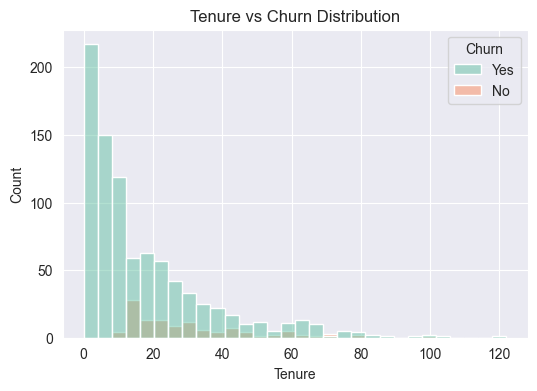

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(x='Tenure',hue= 'Churn', data=df, palette="Set2")
plt.title('Tenure vs Churn Distribution')
plt.show()

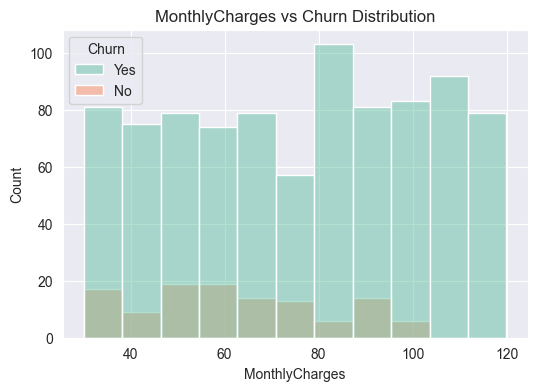

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(x='MonthlyCharges',hue= 'Churn', data=df, palette="Set2")
plt.title('MonthlyCharges vs Churn Distribution')
plt.show()

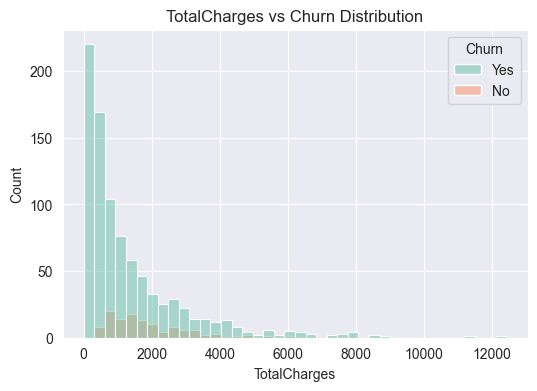

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(x='TotalCharges',hue= 'Churn', data=df, palette="Set2")
plt.title('TotalCharges vs Churn Distribution')
plt.show()

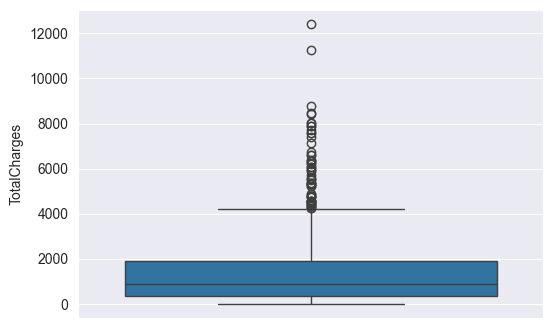

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(df, y = "TotalCharges")
plt.show()

In [21]:
df.drop(columns = ['CustomerID',], inplace = True)

In [22]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No': 0})
df['Churn'].value_counts()

Churn
1    883
0    117
Name: count, dtype: int64

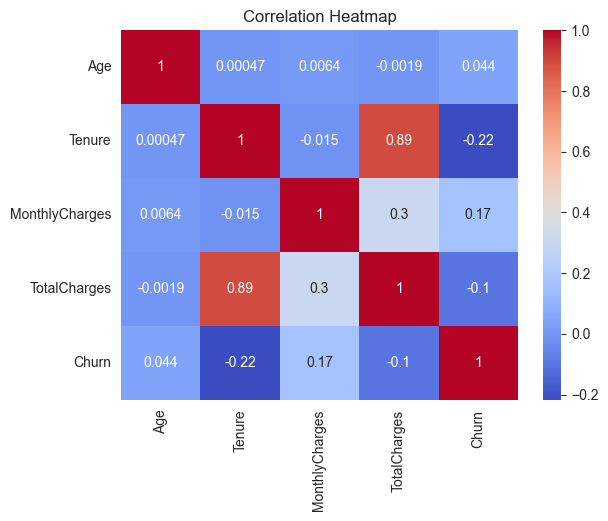

In [23]:
corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis
1. Tenure and Monthly charges exhibits strong correlation. Customers having longer tenure have higher monthly charges.
2. Churn and Tenure shows strong negative correlation. Customers having longer tenure are less likely to churn.
3. Churn shows positive correlation with churn. Customers having higher monthly charges are slightly more likely to churn.

In [24]:
df.describe()

,Age,Tenure,MonthlyCharges,TotalCharges,Churn
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,44.674000,18.97300,74.391290,1404.364060,0.883000
std,9.797741,18.89257,25.712083,1571.755048,0.321581
min,12.000000,0.00000,30.000000,0.000000,0.000000
25%,38.000000,5.00000,52.357500,345.217500,1.000000
50%,45.000000,13.00000,74.060000,872.870000,1.000000
75%,51.000000,26.00000,96.102500,1900.175000,1.000000
max,83.000000,122.00000,119.960000,12416.250000,1.000000


In [25]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges', 'ContractType',
       'InternetService', 'TotalCharges', 'TechSupport', 'Churn'],
      dtype='object')

In [26]:
df.head()

,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,1
1,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,1
2,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,1
3,60,Female,8,102.34,One-Year,DSL,818.72,Yes,1
4,42,Male,32,69.01,Month-to-Month,Unknown,2208.32,No,1


In [27]:
corr['Churn'].sort_values(ascending = False)

Churn             1.000000
MonthlyCharges    0.167773
Age               0.044115
TotalCharges     -0.101523
Tenure           -0.217675
Name: Churn, dtype: float64

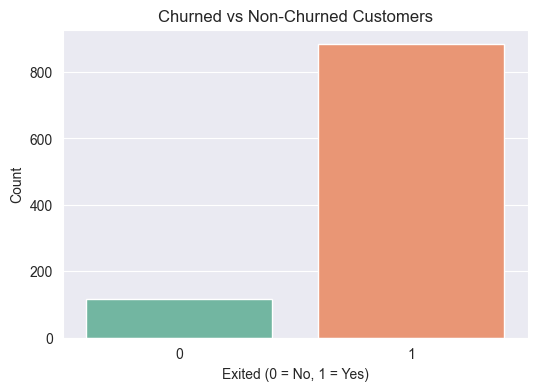

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette="Set2")
plt.title("Churned vs Non-Churned Customers")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [29]:
df_final = pd.get_dummies(df, drop_first= True)
df_final

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic,InternetService_Unknown,TechSupport_Yes
0,49,4,88.35,353.40,1,True,False,False,True,False,True
1,43,0,36.67,0.00,1,True,False,False,True,False,True
2,51,2,63.79,127.58,1,False,False,False,True,False,False
3,60,8,102.34,818.72,1,False,True,False,False,False,True
4,42,32,69.01,2208.32,1,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
995,42,41,37.14,1522.74,1,True,False,False,True,False,True
996,62,9,80.93,728.37,1,True,False,False,False,True,False
997,51,15,111.72,1675.80,1,False,False,False,True,False,True
998,39,68,65.67,4465.56,1,True,True,False,False,True,False


In [30]:
df_final = df_final.astype(int)
df_final

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic,InternetService_Unknown,TechSupport_Yes
0,49,4,88,353,1,1,0,0,1,0,1
1,43,0,36,0,1,1,0,0,1,0,1
2,51,2,63,127,1,0,0,0,1,0,0
3,60,8,102,818,1,0,1,0,0,0,1
4,42,32,69,2208,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
995,42,41,37,1522,1,1,0,0,1,0,1
996,62,9,80,728,1,1,0,0,0,1,0
997,51,15,111,1675,1,0,0,0,1,0,1
998,39,68,65,4465,1,1,1,0,0,1,0


In [31]:
df_final.columns

Index(['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Gender_Male', 'ContractType_One-Year', 'ContractType_Two-Year',
       'InternetService_Fiber Optic', 'InternetService_Unknown',
       'TechSupport_Yes'],
      dtype='object')

In [32]:
df_final.shape

(1000, 11)

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier

In [34]:
X = df_final.drop(['Churn'], axis = 1)
y = df_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.20, random_state=42)

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [36]:
lr = LogisticRegression()
lr.fit(X_train_scaled,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [37]:
lr_pred = lr.predict(X_test_scaled)

In [38]:
accuracy_score(y_test, lr_pred)

0.96

In [39]:
confusion_matrix(y_test, lr_pred)

array([[ 18,   5],
       [  3, 174]])

In [40]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82        23
           1       0.97      0.98      0.98       177

    accuracy                           0.96       200
   macro avg       0.91      0.88      0.90       200
weighted avg       0.96      0.96      0.96       200



In [41]:
y_prob = lr.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
auc_score

0.9842790469172195

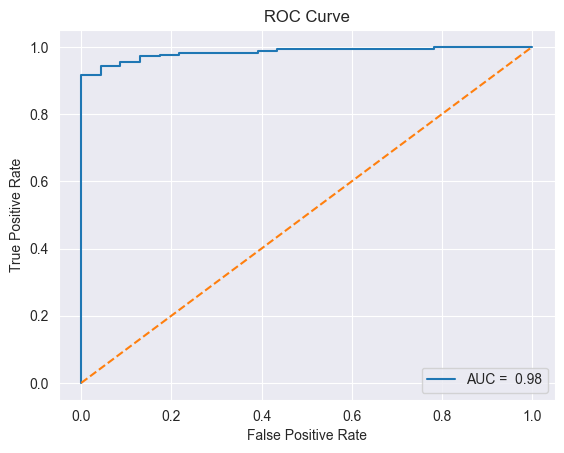

In [42]:
plt.plot(fpr, tpr, label = f'AUC = {auc_score: .2f}')
plt.plot([0,1],[0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [43]:
y_prob.min()

np.float64(0.0005808211772272738)

In [44]:
y_prob.max()

np.float64(0.9999999549279672)

### Decision Tree

In [45]:
dt = DecisionTreeClassifier()
dt.fit(X_train,  y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [46]:
dt_pred = dt.predict(X_test)

In [47]:
accuracy_score(y_test, dt_pred)

0.995

In [48]:
confusion_matrix(y_test,dt_pred)

array([[ 23,   0],
       [  1, 176]])

In [49]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.99      1.00       177

    accuracy                           0.99       200
   macro avg       0.98      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [50]:
dt_prob = dt.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, dt_prob)
auc_score = roc_auc_score(y_test, dt_prob)
auc_score

0.9971751412429379

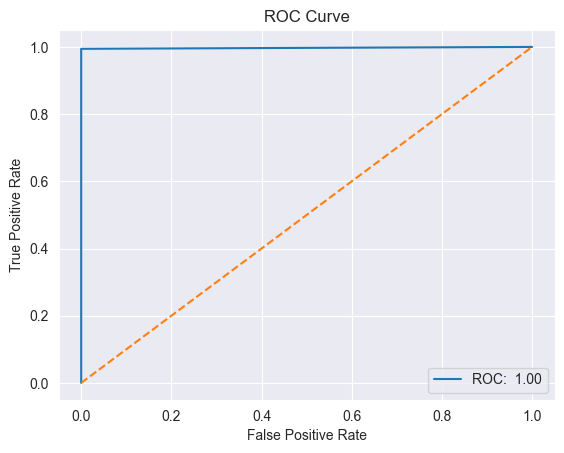

In [51]:
plt.plot(fpr, tpr, label = f'ROC: {auc_score: .2f}')
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Random forest

In [52]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
rf_pred = rf.predict(X_test)

In [54]:
accuracy_score(y_test,rf_pred)

1.0

In [55]:
confusion_matrix(y_test,rf_pred)

array([[ 23,   0],
       [  0, 177]])

In [56]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00       177

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [57]:
rf_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
auc_score= roc_auc_score(y_test, rf_prob)
auc_score

1.0

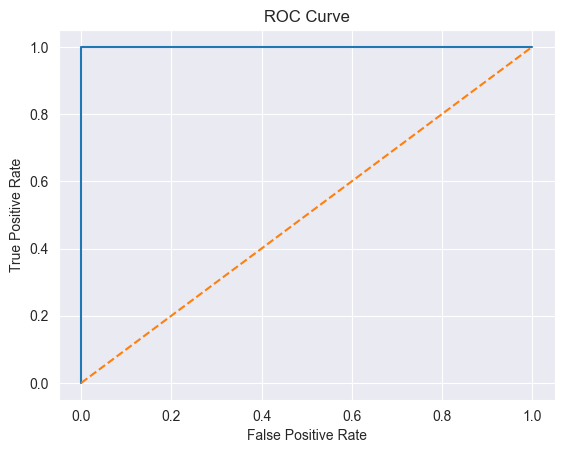

In [58]:
plt.plot(fpr, tpr, label= f'ROC: {auc_score: .2f}')
plt.plot([0,1],[0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

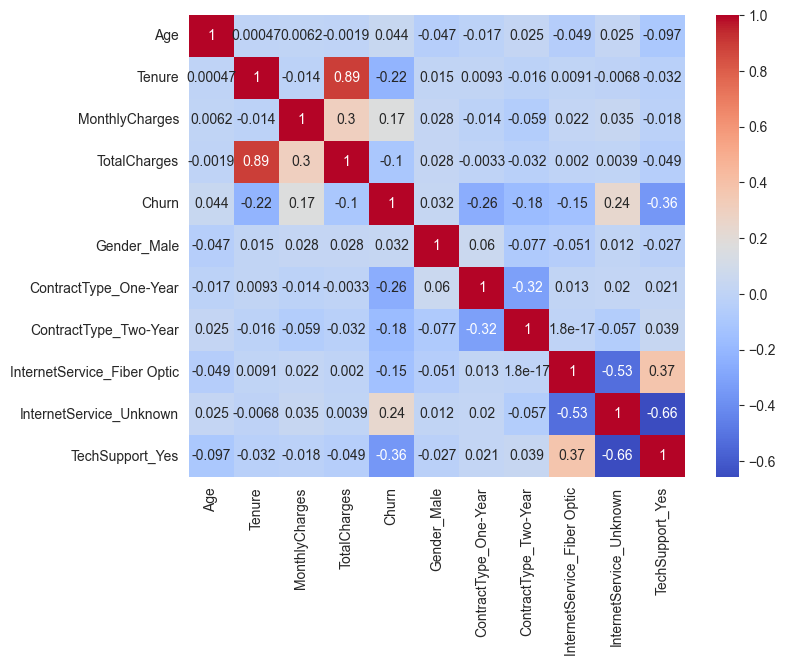

In [59]:
corr = df_final.corr(numeric_only=True)
plt.figure(figsize = (8,6))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.show()

In [60]:
importance = pd.DataFrame({
  'Features': X.columns,
  'Importance': rf.feature_importances_
})
importance.sort_values(by = 'Importance', ascending = False)

,Features,Importance
5,ContractType_One-Year,0.175881
9,TechSupport_Yes,0.175387
1,Tenure,0.174532
6,ContractType_Two-Year,0.140429
2,MonthlyCharges,0.138220
3,TotalCharges,0.108956
0,Age,0.038531
8,InternetService_Unknown,0.030075
7,InternetService_Fiber Optic,0.011398
4,Gender_Male,0.006591


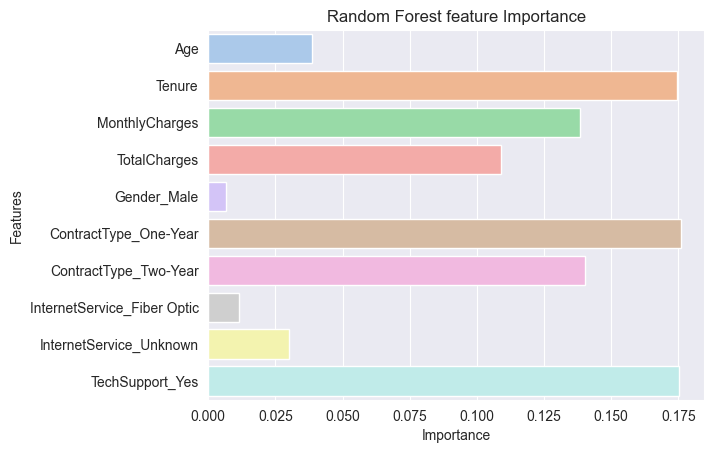

In [61]:
sns.barplot(x = 'Importance', y = 'Features', data = importance, palette = 'pastel')
plt.title('Random Forest feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [62]:
import joblib

In [63]:
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(rf, 'CustomerChurn_RFModel.pkl')

['CustomerChurn_RFModel.pkl']

In [64]:
import os
os.listdir()

['CustomerChurn_RFModel.pkl', 'Customer_churn.ipynb', 'scaler.pkl']